## Imports

In [11]:
import pandas as pd
import time
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import matthews_corrcoef, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

## PreProcess

In [12]:
RS = 678723
data = pd.read_csv("../../data/processed/final_dataset.csv")

feature_cols = [
    'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'loudness', 'duration_sec', 'popularity'
]

X = data[feature_cols]
y = data['macro_genre']
genres = data['macro_genre'].unique()

X.head()
# y.head()
print(genres)

['Acoustic' 'Metal' 'Electronic' 'Latin' 'Hip-Hop']


In [13]:
le = LabelEncoder()
y_labels = le.fit_transform(y)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_labels, test_size=0.25, random_state=RS, stratify=y_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=RS, stratify=y_train_val
)

# scaling: fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# DTree

In [14]:
def DTree_tune(X_train, X_val, y_train, y_val, random_state, max_depth_list, balanced=False):
    val_mcc = {}
    val_acc = {}
    best_depth = None
    best_val_mcc = -np.inf
    best_model = None

    for depth in max_depth_list:
        start_time = time.perf_counter()

        if depth == 0:
            if balanced:
                dtc = DecisionTreeClassifier(
                    class_weight='balanced',
                    criterion='entropy',
                    random_state=random_state
                )
            else:

                dtc = DecisionTreeClassifier(
                    criterion='entropy',
                    random_state=random_state
                )
        else:
            if balanced:
                dtc = DecisionTreeClassifier(
                    class_weight='balanced',
                    criterion='entropy',
                    max_depth=depth,
                    random_state=random_state
                )
            else:
                dtc = DecisionTreeClassifier(
                    criterion='entropy',
                    max_depth=depth,
                    random_state=random_state
                )

        dtc.fit(X_train, y_train)
        y_pred = dtc.predict(X_val)

        mcc = matthews_corrcoef(y_val, y_pred)
        acc = accuracy_score(y_val, y_pred)

        val_mcc[depth] = mcc
        val_acc[depth] = acc

        if mcc > best_val_mcc:
            best_val_mcc = mcc
            best_depth = depth
            best_model = dtc


        elapsed = time.perf_counter() - start_time
        print(f"depth={depth} mcc={mcc:.4f} acc={acc:.4f} time={elapsed:.4f}s")

    return val_mcc, val_acc, best_model, best_depth

max_depth = [0, 2, 4, 6, 8, 10, 15, 20]
val_mcc, val_acc, best_model, best_depth = DTree_tune(
    X_train_scaled, X_val_scaled, y_train, y_val, RS, max_depth
)

depth=0 mcc=0.5661 acc=0.6791 time=6.3547s
depth=2 mcc=0.5335 acc=0.6462 time=0.6124s
depth=4 mcc=0.5536 acc=0.6748 time=1.1691s
depth=6 mcc=0.6101 acc=0.7143 time=1.8872s
depth=8 mcc=0.6331 acc=0.7291 time=2.6750s
depth=10 mcc=0.6457 acc=0.7393 time=3.2102s
depth=15 mcc=0.6297 acc=0.7268 time=5.1127s
depth=20 mcc=0.5820 acc=0.6908 time=6.1885s


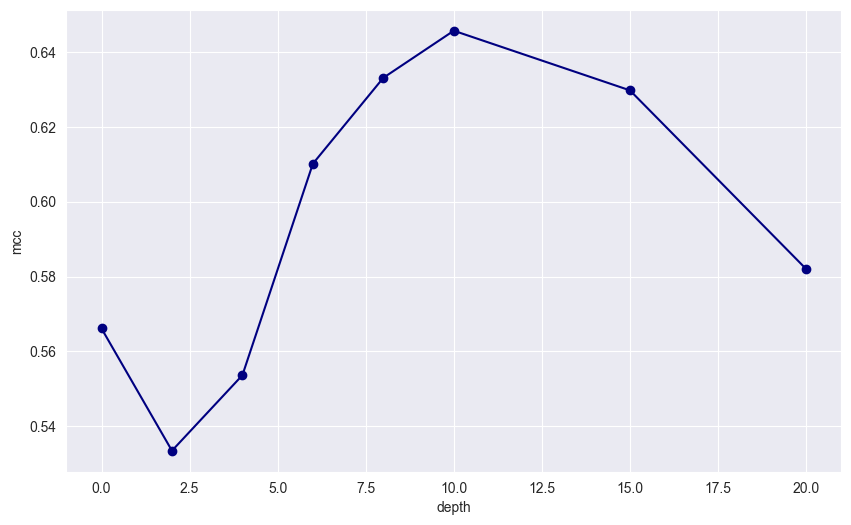

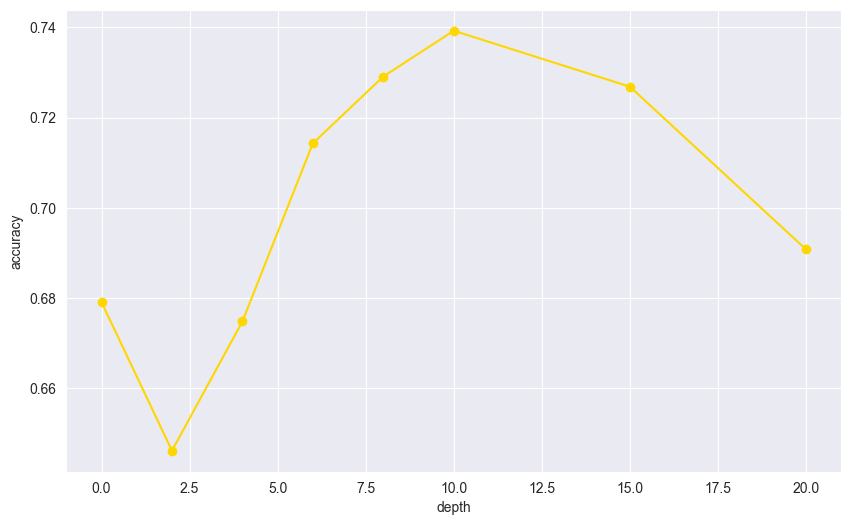

In [15]:
## DT MCC SCORE
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()

In [16]:
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

if best_depth == 0:
    final_model = DecisionTreeClassifier(criterion='entropy', random_state=RS)
else:
    final_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RS)

final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test_scaled)
test_mcc = matthews_corrcoef(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Selected best_depth =", best_depth, "val_mcc =", val_mcc[best_depth])
print("Test MCC:", test_mcc)
print("Test Accuracy:", test_acc)
print("Classification report on test set:\n", classification_report(y_test, y_test_pred, zero_division=0))

Selected best_depth = 10 val_mcc = 0.6456753673118859
Test MCC: 0.6456586829781527
Test Accuracy: 0.7387450989544436
Classification report on test set:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77     40886
           1       0.73      0.78      0.75     61763
           2       0.52      0.47      0.50      3926
           3       0.69      0.73      0.71     26818
           4       0.75      0.70      0.73     37999

    accuracy                           0.74    171392
   macro avg       0.70      0.69      0.69    171392
weighted avg       0.74      0.74      0.74    171392



# Decision Tree with class weight balancing

In [17]:
max_depth = [0, 2, 4, 6, 8, 10, 15, 20]
val_mcc_balanced, val_acc_balanced, best_model, best_depth = DTree_tune(
    X_train_scaled, X_val_scaled, y_train, y_val, RS, max_depth, balanced=True
)

X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

if best_depth == 0:
    final_model = DecisionTreeClassifier(criterion='entropy', random_state=RS, class_weight='balanced')
else:
    final_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RS, class_weight='balanced')

final_model.fit(X_train_full, y_train_full)

y_test_pred = final_model.predict(X_test_scaled)
test_mcc = matthews_corrcoef(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Selected best_depth =", best_depth, "val_mcc =", val_mcc[best_depth])
print("Test MCC:", test_mcc)
print("Test Accuracy:", test_acc)
print("Classification report on test set:\n", classification_report(y_test, y_test_pred, zero_division=0))

depth=0 mcc=0.5582 acc=0.6733 time=6.9903s
depth=2 mcc=0.3382 acc=0.4186 time=0.6523s
depth=4 mcc=0.5370 acc=0.6250 time=1.2720s
depth=6 mcc=0.5633 acc=0.6570 time=2.0879s
depth=8 mcc=0.6027 acc=0.6919 time=2.6781s
depth=10 mcc=0.6196 acc=0.7052 time=4.6609s
depth=15 mcc=0.6184 acc=0.7093 time=7.4473s
depth=20 mcc=0.5761 acc=0.6838 time=6.6475s
Selected best_depth = 10 val_mcc = 0.6456753673118859
Test MCC: 0.619311003950169
Test Accuracy: 0.7045894790888723
Classification report on test set:
               precision    recall  f1-score   support

           0       0.81      0.74      0.77     40886
           1       0.81      0.62      0.71     61763
           2       0.24      0.89      0.38      3926
           3       0.64      0.76      0.69     26818
           4       0.70      0.75      0.72     37999

    accuracy                           0.70    171392
   macro avg       0.64      0.75      0.65    171392
weighted avg       0.75      0.70      0.72    171392



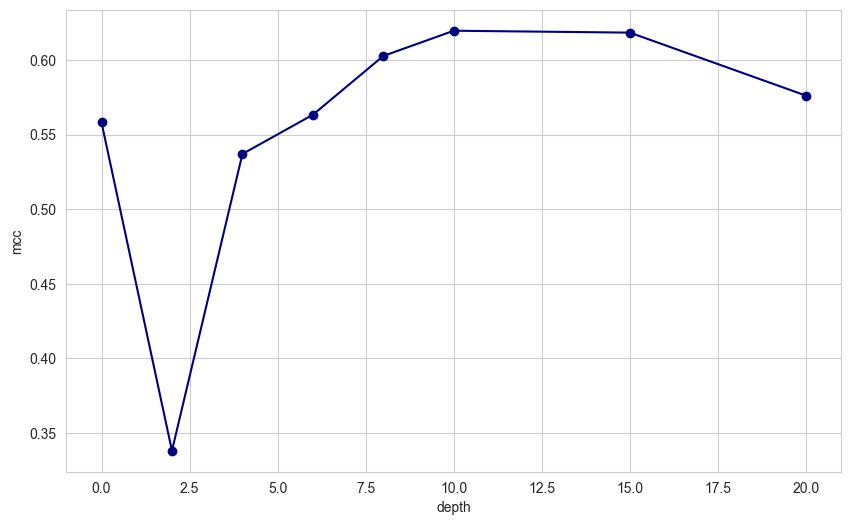

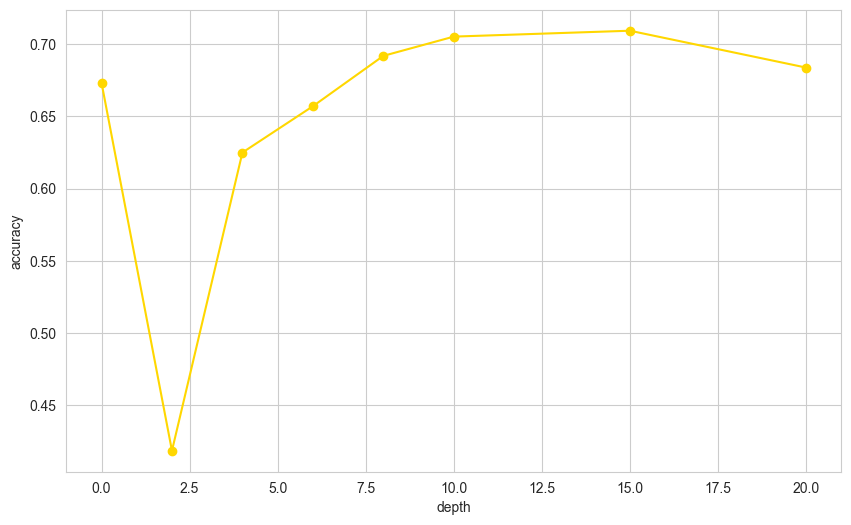

In [18]:
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc_balanced.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc_balanced.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()

# Decision Tree with smote

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=RS)
X_train_rs, y_train_rs = smote.fit_resample(X_train_scaled, y_train)


max_depth = [0, 2, 4, 6, 8, 10, 15, 20]
val_mcc_smote, val_acc_smote, best_model, best_depth = DTree_tune(
    X_train_rs, X_val_scaled, y_train_rs, y_val, RS, max_depth
)


depth=0 mcc=0.5617 acc=0.6709 time=18.1112s
depth=2 mcc=0.3395 acc=0.4200 time=1.8692s
depth=4 mcc=0.5166 acc=0.6004 time=3.5827s
depth=6 mcc=0.5666 acc=0.6616 time=5.6728s
depth=8 mcc=0.6051 acc=0.6960 time=7.7655s
depth=10 mcc=0.6167 acc=0.7019 time=9.3958s
depth=15 mcc=0.6171 acc=0.7067 time=12.9730s
depth=20 mcc=0.5785 acc=0.6817 time=15.6785s


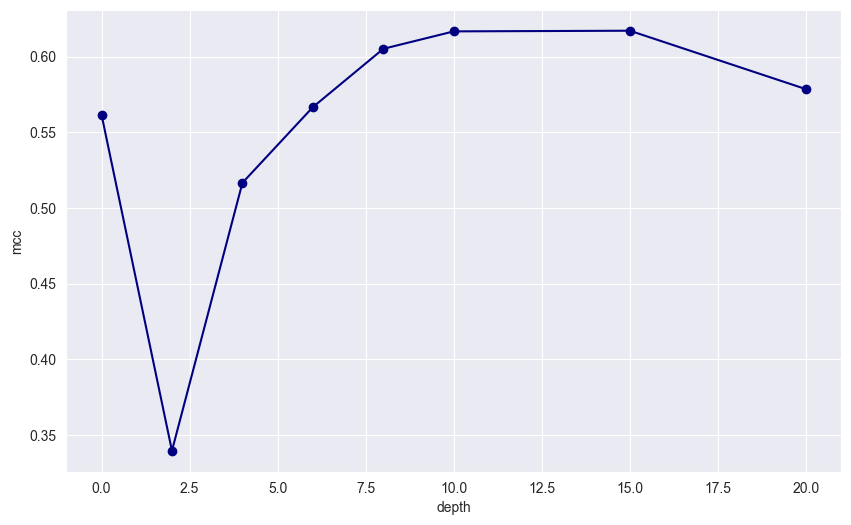

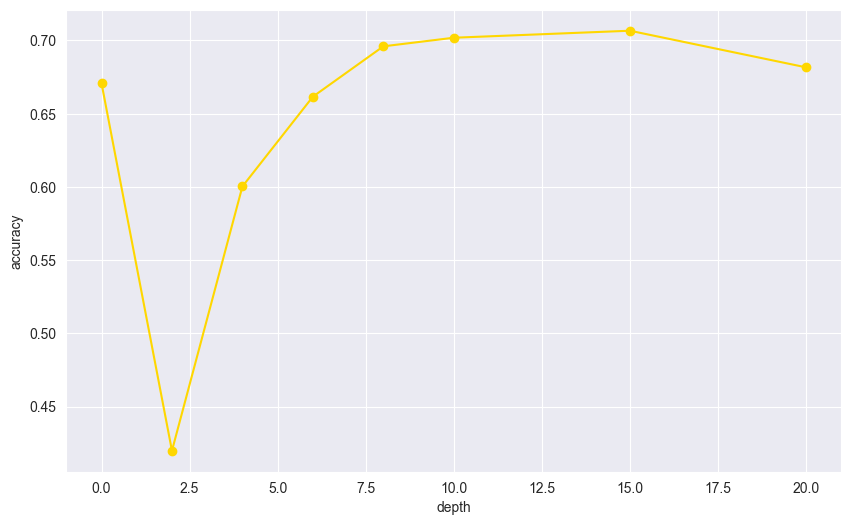

In [20]:
## DT MCC SCORE
fig = (10, 6)

plt.figure(figsize=fig)
plt.plot(max_depth, list(val_mcc_smote.values()), marker="o", color="navy")
plt.xlabel("depth")
plt.ylabel("mcc")
plt.show()


plt.figure(figsize=fig)
plt.plot(max_depth, list(val_acc_smote.values()), marker="o", color="gold")
plt.xlabel("depth")
plt.ylabel("accuracy")

plt.show()

In [21]:
X_train_full = np.vstack([X_train_scaled, X_val_scaled])
y_train_full = np.concatenate([y_train, y_val])

if best_depth == 0:
    final_model = DecisionTreeClassifier(criterion='entropy', random_state=RS)
else:
    final_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=RS)

X_train_full_res, y_train_full_res = smote.fit_resample(X_train_full, y_train_full)
final_model.fit(X_train_full_res, y_train_full_res)

y_test_pred = final_model.predict(X_test_scaled)
test_mcc = matthews_corrcoef(y_test, y_test_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Selected best_depth =", best_depth, "val_mcc =", val_mcc[best_depth])
print("Test MCC:", test_mcc)
print("Test Accuracy:", test_acc)
print("Classification report on test set:\n", classification_report(y_test, y_test_pred, zero_division=0))

Selected best_depth = 15 val_mcc = 0.6297438510656256
Test MCC: 0.6207717976110688
Test Accuracy: 0.7088895631067961
Classification report on test set:
               precision    recall  f1-score   support

           0       0.78      0.73      0.76     40886
           1       0.81      0.63      0.71     61763
           2       0.29      0.79      0.43      3926
           3       0.64      0.77      0.70     26818
           4       0.69      0.76      0.72     37999

    accuracy                           0.71    171392
   macro avg       0.64      0.74      0.66    171392
weighted avg       0.74      0.71      0.71    171392



# Multi model plot

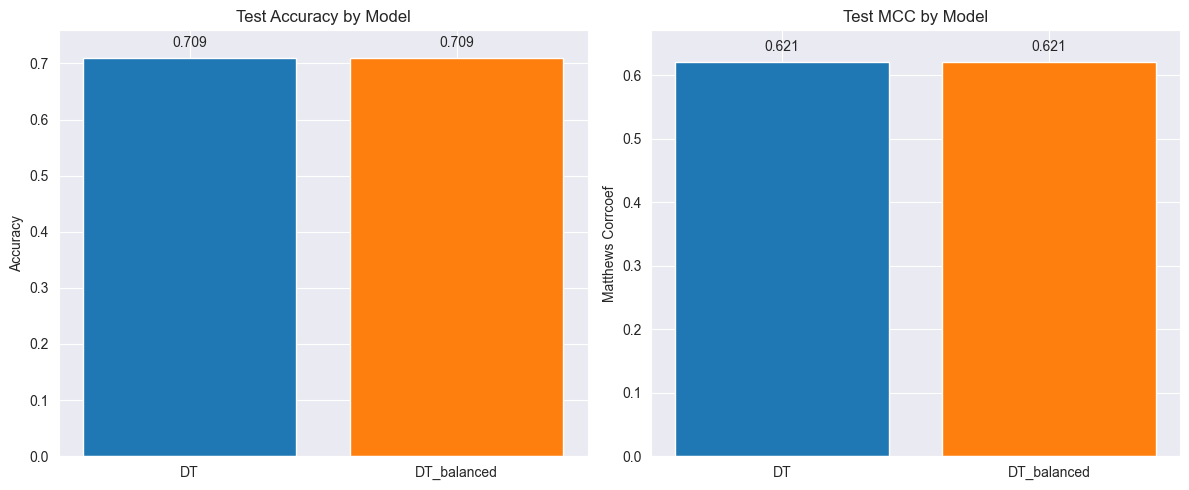

In [23]:
# python
import numpy as np
import matplotlib.pyplot as plt

# --- helper to pick first available variable from a list of candidates ---
def pick(globs, candidates):
    for name in candidates:
        if name in globs:
            return globs[name]
    return np.nan

g = globals()
# candidate names used in your notebook and in earlier snippet
acc_candidates = [
    "test_acc", "test_acc_baseline", "test_acc_dt", "acc_dt",
    "acc_baseline", "acc_bal", "acc_smote", "test_acc_balanced", "test_acc_smote"
]
mcc_candidates = [
    "test_mcc", "test_mcc_baseline", "test_mcc_dt", "mcc_dt",
    "mcc_baseline", "mcc_bal", "mcc_smote", "test_mcc_balanced", "test_mcc_smote"
]

acc_dt = pick(g, ["acc_dt", "test_acc", "test_acc_dt", "test_acc_baseline"])
acc_bal = pick(g, ["acc_bal", "test_acc_balanced", "acc_baseline", "test_acc"])
acc_smote = pick(g, ["acc_smote", "test_acc_smote", "acc_smote"])

mcc_dt = pick(g, ["mcc_dt", "test_mcc", "test_mcc_dt", "test_mcc_baseline"])
mcc_bal = pick(g, ["mcc_bal", "test_mcc_balanced", "mcc_baseline", "test_mcc"])
mcc_smote = pick(g, ["mcc_smote", "test_mcc_smote", "mcc_smote"])

models = ["DT", "DT_balanced", "DT_SMOTE"]
accuracies = [acc_dt, acc_bal, acc_smote]
mccs = [mcc_dt, mcc_bal, mcc_smote]

# --- small helper to annotate bars and handle NaNs ---
def bar_plot(values, labels, title, ylabel, ax):
    cmap = plt.get_cmap("tab10")
    bars = ax.bar(labels, values, color=cmap(range(len(labels))))
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    # set sensible ylim ignoring nan
    finite = [v for v in values if np.isfinite(v)]
    if finite:
        ymin = min(0, min(finite) - 0.05)
        ymax = max(finite) + 0.05
        ax.set_ylim(ymin, ymax)
    for bar, val in zip(bars, values):
        if np.isfinite(val):
            txt = f"{val:.3f}"
        else:
            txt = "n/a"
        ax.annotate(txt, xy=(bar.get_x() + bar.get_width() / 2, 0 if not np.isfinite(val) else val),
                    xytext=(0, 6), textcoords="offset points", ha="center", va="bottom")

# --- draw plots side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bar_plot(accuracies, models, "Test Accuracy by Model", "Accuracy", axes[0])
bar_plot(mccs, models, "Test MCC by Model", "Matthews Corrcoef", axes[1])
plt.tight_layout()
plt.show()